# To implement a CNN without using built in library

In [49]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

## Load and process data

In [50]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X, y = mnist.data, mnist.target.astype(np.uint8)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Labels range: {max(y)} to {min(y)}")

Features shape: (70000, 784)
Labels shape: (70000,)
Labels range: 9 to 0


In [51]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"Train data shape: {x_train.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Train data shape: (56000, 784)
Train labels shape: (56000,)
Test data shape: (14000, 784)
Test labels shape: (14000,)


In [52]:
def unflatten_numbers(x):
    return np.reshape(x, (-1, 28, 28))

unflattened_x_train = unflatten_numbers(x_train)
unflattened_x_test = unflatten_numbers(x_test)
print(unflattened_x_train.shape)
print(unflattened_x_test.shape)

(56000, 28, 28)
(14000, 28, 28)


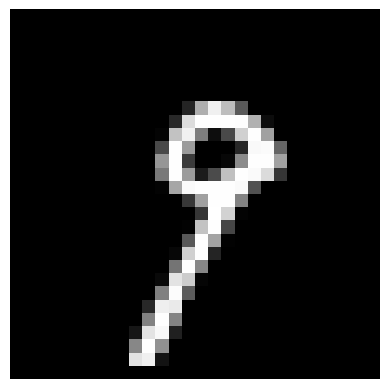

In [53]:
plt.imshow(unflattened_x_train[1], cmap='gray')
plt.axis('off')
plt.show()

In [54]:
def normalization(x):
    return x / 255.0

normalized_x_train = normalization(x_train)
normalized_x_test = normalization(x_test)

train_images = normalized_x_train.reshape(-1, 28, 28)
test_images = normalized_x_test.reshape(-1, 28, 28)

print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Pixel range: [{train_images.min():.2f}, {train_images.max():.2f}]")


Train images shape: (56000, 28, 28)
Test images shape: (14000, 28, 28)
Pixel range: [0.00, 1.00]


In [55]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(categories='auto')

y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.fit_transform(y_test.reshape(-1,1))

y_train_oh = y_train_oh.toarray()
y_test_oh = y_test_oh.toarray()
# print(type(y_train_oh))

print(y_train_oh.shape)
print(y_test_oh.shape)

(56000, 10)
(14000, 10)


## Constructing the network

In [56]:
def forward_convolution(x, w, b):
    h_in, w_in = x.shape
    h_out = h_in - 2
    w_out = w_in - 2
    z = np.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            patch = x[i:i+3, j:j+3]
            z[i, j] = np.sum(patch * w) + b

    a = np.maximum(0, z)
    return a, (x, w, z)


In [57]:
def loss_gradient(y, y_pred):
    return y_pred - y


In [58]:
def compute_local_gradients(dA, z):
    relu_derivative = (z > 0).astype(float)
    dz = dA * relu_derivative
    return dz


In [59]:
def update_filter_weights(x, dz, w, b, lr=0.01):
    dw = np.zeros((3, 3))
    h_dz, w_dz = dz.shape

    for i in range(3):
        for j in range(3):
            patch = x[i : i + h_dz, j : j + w_dz]
            dw[i, j] = np.sum(patch * dz)

    db = np.sum(dz)
    return w - lr * dw, b - lr * db


In [60]:
def compute_previous_layer_gradient(dz, w):
    w_rot = np.rot90(w, 2)
    dz_padded = np.pad(dz, ((2, 2), (2, 2)), mode='constant')
    h_out = dz_padded.shape[0] - 2
    w_out = dz_padded.shape[1] - 2
    dx = np.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            patch = dz_padded[i : i+3, j : j+3]
            dx[i, j] = np.sum(patch * w_rot)

    return dx


In [61]:
def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()


## Training

In [62]:
np.random.seed(42)
epochs = 3
learning_rate = 0.01

w1 = np.random.randn(3, 3) * 0.1
b1 = 0.0

w2 = np.random.randn(3, 3) * 0.1
b2 = 0.0

w_dense = np.random.randn(10, 576) * 0.01
b_dense = np.zeros((10, 1))

print(f"w1 shape: {w1.shape}")
print(f"w2 shape: {w2.shape}")
print(f"w_dense shape: {w_dense.shape}")
print(f"b_dense shape: {b_dense.shape}")


w1 shape: (3, 3)
w2 shape: (3, 3)
w_dense shape: (10, 576)
b_dense shape: (10, 1)


In [ ]:
loss_history = []
acc_history = []

for epoch in range(epochs):
    total_loss = 0
    correct = 0

    for i in range(len(train_images)):
        x = train_images[i]
        y_true = y_train_oh[i].reshape(10, 1)

        a1, cache1 = forward_convolution(x, w1, b1)
        a2, cache2 = forward_convolution(a1, w2, b2)

        v = a2.flatten().reshape(-1, 1)

        z_out = np.dot(w_dense, v) + b_dense
        y_pred = softmax(z_out)

        loss = -np.sum(y_true * np.log(y_pred + 1e-8))
        total_loss += loss

        if np.argmax(y_pred) == np.argmax(y_true):
            correct += 1

        dz_out = loss_gradient(y_true, y_pred)

        dw_dense = np.dot(dz_out, v.T)
        db_dense = dz_out
        dv = np.dot(w_dense.T, dz_out)

        da2 = dv.reshape(a2.shape)

        dz2 = compute_local_gradients(da2, cache2[2])
        da1 = compute_previous_layer_gradient(dz2, cache2[1])
        w2, b2 = update_filter_weights(cache2[0], dz2, cache2[1], b2, learning_rate)

        dz1 = compute_local_gradients(da1, cache1[2])
        w1, b1 = update_filter_weights(cache1[0], dz1, cache1[1], b1, learning_rate)

        w_dense = w_dense - learning_rate * dw_dense
        b_dense = b_dense - learning_rate * db_dense

    avg_loss = total_loss / len(train_images)
    accuracy = correct / len(train_images)
    loss_history.append(avg_loss)
    acc_history.append(accuracy)
    print(f"Epoch {epoch + 1}/{epochs}  Loss: {avg_loss:.4f}  Accuracy: {accuracy * 100:.2f}%")
